# 실험 2: Diffusion 오버샘플링, DDPM 30스텝

In [ ]:
import os
import subprocess

GPU_ID = None  # None이면 아래에서 가장 한가한 GPU를 자동 선택. 고정하려면 "0" / "1" / "2"처럼 지정


def pick_free_gpu():
    out = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=index,memory.used,utilization.gpu", "--format=csv,noheader,nounits"]
    ).decode()
    rows = [tuple(int(v) for v in line.split(",")) for line in out.strip().splitlines()]
    for idx, mem, util in rows:
        print(f"  GPU {idx}: memory {mem} MiB, util {util}%")
    return str(min(rows, key=lambda r: (r[1], r[2]))[0])


if GPU_ID is None:
    GPU_ID = pick_free_gpu()
os.environ["CUDA_VISIBLE_DEVICES"] = GPU_ID
print("사용 GPU:", GPU_ID)
RUN_SEEDS = list(range(10))  # seed 0~9 전부

  GPU 0: memory 848 MiB, util 9%
사용 GPU: 0


## 0. 라이브러리 & 공통 유틸 / 모델 정의

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
from pathlib import Path
_d = Path.cwd().resolve()
while not (_d / "models.py").exists():
    if _d.parent == _d:
        raise FileNotFoundError("상위 폴더 어디에도 models.py가 없습니다")
    _d = _d.parent
if str(_d) not in sys.path:
    sys.path.insert(0, str(_d))
print("공용 모듈 경로:", _d)

import os
import time
from collections import Counter

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from torchvision import transforms as T
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from models import Unet, Classifier
from utils import (
    set_seed, DEVICE, SEEDS, EMA,
    evaluate_classifier, metrics_to_rows, append_result_rows,
)
from diffusion import GaussianDiffusion
from data import (
    build_imbalanced_split, CachedDataset, CachedSubset, BalancedDataset,
    generate_balanced_fake, draw_from_pool,
)

SEEDS = [s for s in SEEDS if s in RUN_SEEDS]

print("device:", DEVICE)
print("모델/유틸/데이터 모듈 로드 완료 (models.py, utils.py, diffusion.py, data.py)")


공용 모듈 경로: 6_diffusion_step_change_experiment
device: cuda
모델/유틸/데이터 모듈 로드 완료 (models.py, utils.py, diffusion.py, data.py)


## 1. 데이터 생성: 불균형 데이터셋

In [ ]:
image_size = 64
channels = 3
batch_size = 40
num_classes = 3

data_root = os.environ.get("DATA_ROOT", "../../data/256")  # 경로

RESULTS_CSV = "exp_diffusion_step_30.csv"
if os.path.exists(RESULTS_CSV):
    os.remove(RESULTS_CSV)

CLASS_NAMES = ["Normal", "Underfill_50FR", "Underfill_Fan"]  # ImageFolder는 폴더명 알파벳순으로 라벨을 매김 (Normal=0, Underfill_50FR=1, Underfill_Fan=2)

train_counts = {0: 800, 1: 80, 2: 80}
test_counts = {0: 100, 1: 100, 2: 100}

transform = T.Compose([
    T.Resize((image_size, image_size)),
    T.ToTensor(),
    T.Lambda(lambda t: (t * 2) - 1),  # [0,1] -> [-1,1]
])

full_dataset = ImageFolder(root=data_root, transform=transform)
assert full_dataset.classes == CLASS_NAMES, full_dataset.classes

full_cached = CachedDataset(full_dataset)


def set_split(seed):
    global train_indices, test_indices, train_dataset, test_dataset
    global train_loader, test_loader, train_labels, test_labels
    train_indices, test_indices = build_imbalanced_split(full_dataset, train_counts, test_counts, seed=seed)

    train_dataset = CachedSubset(full_cached, train_indices)
    test_dataset = CachedSubset(full_cached, test_indices)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True,
                               pin_memory=(DEVICE == "cuda"))
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                              pin_memory=(DEVICE == "cuda"))

    train_labels = [full_dataset.samples[i][1] for i in train_indices]
    test_labels = [full_dataset.samples[i][1] for i in test_indices]


set_split(0)  # 미리보기/학습량 기준(BASELINE_STEPS) 계산용 초기 분할
print("SEEDS:", SEEDS)
print("Train label distribution:", Counter(train_labels))
print("Test  label distribution:", Counter(test_labels))


SEEDS: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Train label distribution: Counter({0: 800, 1: 80, 2: 80})
Test  label distribution: Counter({0: 100, 1: 100, 2: 100})


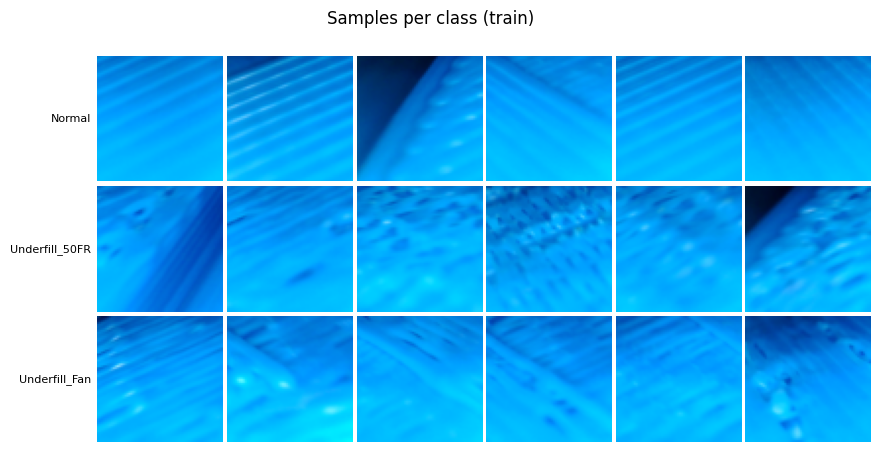

In [ ]:
def denorm(x):
    return (x + 1) / 2

W, L, R = 9, 0.13, 0.99
cell = W * (R - L) / 6
H = num_classes * cell + 0.6
fig, axes = plt.subplots(num_classes, 6, figsize=(W, H))
for cls in range(num_classes):
    idxs = [i for i, y in enumerate(train_labels) if y == cls][:6]
    for j, idx in enumerate(idxs):
        img, _ = train_dataset[idx]
        axes[cls, j].imshow(denorm(img).permute(1, 2, 0).numpy())
        axes[cls, j].axis("off")
    axes[cls, 0].text(-0.05, 0.5, CLASS_NAMES[cls], transform=axes[cls, 0].transAxes,
                      ha="right", va="center", fontsize=8)
plt.suptitle("Samples per class (train)")
plt.subplots_adjust(left=L, right=R, bottom=0.05 / H, top=1 - 0.55 / H, wspace=0.03, hspace=0.03)
plt.show()

## 2. Diffusion / 평가 공통 유틸

In [14]:
timesteps = 30
ddpm = GaussianDiffusion(timesteps=timesteps, image_size=image_size, channels=channels)

print("diffusion/평가 유틸 정의 완료")



CLASSIFIER_EPOCHS_REF = 50
BASELINE_STEPS = len(train_loader) * CLASSIFIER_EPOCHS_REF
print(f"분류기 학습 기준 step 수 (BASELINE_STEPS) = {len(train_loader)} batches/epoch "
      f"x {CLASSIFIER_EPOCHS_REF} epochs = {BASELINE_STEPS}")

DIFFUSION_EPOCHS_REF = 700
EMA_DECAY = 0.999


def train_classifier_for_steps(loader, total_steps, seed, tag="Classifier"):
    set_seed(seed)
    device = DEVICE

    classifier = Classifier(num_classes=num_classes, img_channels=channels).to(device)
    opt_c = torch.optim.Adam(classifier.parameters(), lr=1e-3)
    cls_loss_fn = nn.CrossEntropyLoss()

    classifier.train()
    data_iter = iter(loader)
    losses = []
    pbar = tqdm(range(total_steps), desc=f"[{tag} seed{seed}] steps", leave=False)
    t0 = time.time()

    for step in pbar:
        try:
            x, y = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            x, y = next(data_iter)

        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        logits = classifier(x)
        loss = cls_loss_fn(logits, y)

        opt_c.zero_grad()
        loss.backward()
        opt_c.step()

        losses.append(loss.item())
        pbar.set_postfix(cls=f"{loss.item():.4f}")

        if (step + 1) % max(1, total_steps // 10) == 0 or step == total_steps - 1:
            print(f"[{tag} seed{seed}] step {step+1}/{total_steps} Cls={np.mean(losses[-50:]):.4f} "
                  f"elapsed={time.time()-t0:.1f}s")

    return classifier


diffusion/평가 유틸 정의 완료
분류기 학습 기준 step 수 (BASELINE_STEPS) = 24 batches/epoch x 50 epochs = 1200


## 실험 2: Diffusion 오버샘플링 (DDPM 30스텝 fake 풀)

In [15]:
def train_diffusion(seed, epochs=None):
    epochs = epochs or DIFFUSION_EPOCHS_REF
    set_seed(seed)
    device = DEVICE

    diffusion = Unet(dim=32, channels=channels, num_classes=num_classes).to(device)
    opt_g = torch.optim.Adam(diffusion.parameters(), lr=2e-4)
    diffusion_loss_fn = nn.MSELoss()
    ema = EMA(diffusion, decay=EMA_DECAY)
    t0 = time.time()

    pbar = tqdm(range(epochs), desc=f"[Diffusion seed{seed}]")
    for epoch in pbar:
        diffusion.train()
        epoch_losses = []
        for x, y in train_loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            t = torch.randint(0, timesteps, (x.size(0),), device=device)
            noise = torch.randn_like(x)
            x_noisy = ddpm.q_sample(x, t, noise)

            pred_noise = diffusion(x_noisy, t, y)
            loss = diffusion_loss_fn(pred_noise, noise)

            opt_g.zero_grad()
            loss.backward()
            opt_g.step()
            ema.update(diffusion)

            epoch_losses.append(loss.item())

        pbar.set_postfix(diff=f"{np.mean(epoch_losses):.4f}")

        if (epoch + 1) % 100 == 0 or epoch == epochs - 1:
            tqdm.write(f"[Diffusion seed{seed}] Epoch {epoch+1}/{epochs} Diff={np.mean(epoch_losses):.4f} "
                  f"elapsed={time.time()-t0:.1f}s")

    return diffusion, ema


def train_classifier_on(dataset, seed, total_steps=None):
    total_steps = total_steps or BASELINE_STEPS
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True,
                         pin_memory=(DEVICE == "cuda"))
    return train_classifier_for_steps(loader, total_steps, seed, tag="Classifier")


DIFFUSION_PATH = "exp_diffusion_step_30_diffusion_seed{seed}.pt"
DIFFUSION_EMA_PATH = "exp_diffusion_step_30_diffusion_ema_seed{seed}.pt"


def load_or_train_diffusion(seed):
    path, ema_path = DIFFUSION_PATH.format(seed=seed), DIFFUSION_EMA_PATH.format(seed=seed)
    if os.path.exists(path) and os.path.exists(ema_path):
        diffusion = Unet(dim=32, channels=channels, num_classes=num_classes).to(DEVICE)
        diffusion.load_state_dict(torch.load(path, map_location=DEVICE))
        ema = EMA(diffusion, decay=EMA_DECAY)
        ema.model.load_state_dict(torch.load(ema_path, map_location=DEVICE))
        print(f"[Diffusion seed{seed}] 학습 건너뜀: {path}, {ema_path} 로드")
        return diffusion, ema, False
    diffusion, ema = train_diffusion(seed)
    return diffusion, ema, True


In [16]:
POOL_PER_CLASS = 800 - 80
POOL_GEN_BATCH = 360  # 한 번의 샘플링 호출로 생성할 장 수 (클래스당 2번 호출)
POOL_PATH = "exp_diffusion_step_30_fake_pool_seed{seed}.pt"


def load_or_build_pool(seed, gen_model, minority_classes=(1, 2)):
    path = POOL_PATH.format(seed=seed)
    if os.path.exists(path):
        pool = torch.load(path, map_location="cpu")
        print(f"[Pool seed{seed}] 생성 건너뜀: {path} 로드")
    else:
        set_seed(seed)
        t0 = time.time()
        pool = generate_balanced_fake(ddpm, gen_model, DEVICE, target_per_class=POOL_PER_CLASS, minority_classes=minority_classes,
                                      batch_size=POOL_GEN_BATCH)
        torch.save(pool, path)
        print(f"[Pool seed{seed}] 클래스당 {POOL_PER_CLASS}장 생성 완료: {time.time()-t0:.1f}초 → {path}")
    return {cls: x.to(DEVICE) for cls, x in pool.items()}


def train_classifier_pool(seed, pool, total_steps=None):
    total_steps = total_steps or BASELINE_STEPS
    set_seed(seed)
    device = DEVICE

    classifier = Classifier(num_classes=num_classes, img_channels=channels).to(device)
    opt_c = torch.optim.Adam(classifier.parameters(), lr=1e-3)
    cls_loss_fn = nn.CrossEntropyLoss()

    classifier.train()
    data_iter = iter(train_loader)
    losses = []
    t0 = time.time()
    pbar = tqdm(range(total_steps), desc=f"[Classifier-pool seed{seed}]")

    for step in pbar:
        try:
            x, y = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader)
            x, y = next(data_iter)
        x, y = x.to(device), y.to(device)

        x_fake, y_fake = draw_from_pool(pool, y, device)
        if x_fake is not None:
            x = torch.cat([x, x_fake], dim=0)
            y = torch.cat([y, y_fake], dim=0)

        loss = cls_loss_fn(classifier(x), y)
        opt_c.zero_grad()
        loss.backward()
        opt_c.step()

        losses.append(loss.item())
        if (step + 1) % 50 == 0:
            pbar.set_postfix(cls=f"{np.mean(losses[-50:]):.4f}")
        if (step + 1) % max(1, total_steps // 10) == 0 or step == total_steps - 1:
            tqdm.write(f"[Classifier-pool seed{seed}] step {step+1}/{total_steps} "
                       f"Cls={np.mean(losses[-50:]):.4f} elapsed={time.time()-t0:.1f}s")

    return classifier


onthefly_rows = []
onthefly_models = {}  # 미리보기용 EMA 모델

for seed in SEEDS:
    set_split(seed)  # seed마다 train/test 분할을 새로 뽑는다 (학습 전에 반드시 먼저)
    print(f"\n===== Diffusion oversampling (pool DDPM{timesteps}) | Seed {seed} =====")
    t0 = time.time()
    diffusion, ema, trained = load_or_train_diffusion(seed)
    if trained:
        torch.save(diffusion.state_dict(), DIFFUSION_PATH.format(seed=seed))
        torch.save(ema.model.state_dict(), DIFFUSION_EMA_PATH.format(seed=seed))

    onthefly_models[seed] = ema.model
    pool = load_or_build_pool(seed, ema.model)
    classifier_otf = train_classifier_pool(seed, pool)
    print(f"[Exp1 seed{seed}] 총 소요 시간: {time.time()-t0:.1f}초")

    metrics = evaluate_classifier(classifier_otf, test_loader, DEVICE, num_classes, CLASS_NAMES)
    rows = metrics_to_rows(metrics, seed, "exp_diffusion_step_30")
    onthefly_rows.extend(rows)
    append_result_rows(rows, RESULTS_CSV)

df_onthefly = pd.DataFrame(onthefly_rows)
df_onthefly


===== Diffusion oversampling (pool DDPM30) | Seed 0 =====
[Diffusion seed0] 학습 건너뜀: exp1_ddpm30_diffusion_seed0.pt, exp1_ddpm30_diffusion_ema_seed0.pt 로드
[Pool seed0] 생성 건너뜀: exp1_ddpm30_fake_pool_seed0.pt 로드


[Classifier-pool seed0]:   0%|          | 0/1200 [00:00<?, ?it/s]

[Classifier-pool seed0] step 120/1200 Cls=0.9493 elapsed=0.2s
[Classifier-pool seed0] step 240/1200 Cls=0.7188 elapsed=0.4s
[Classifier-pool seed0] step 360/1200 Cls=0.5950 elapsed=0.6s
[Classifier-pool seed0] step 480/1200 Cls=0.4800 elapsed=0.8s
[Classifier-pool seed0] step 600/1200 Cls=0.4126 elapsed=0.9s
[Classifier-pool seed0] step 720/1200 Cls=0.3201 elapsed=1.1s
[Classifier-pool seed0] step 840/1200 Cls=0.2936 elapsed=1.3s
[Classifier-pool seed0] step 960/1200 Cls=0.2639 elapsed=1.5s
[Classifier-pool seed0] step 1080/1200 Cls=0.2625 elapsed=1.7s
[Classifier-pool seed0] step 1200/1200 Cls=0.2360 elapsed=1.8s
[Exp1 seed0] 총 소요 시간: 1.9초
===== Evaluation =====
Accuracy        : 0.8367
Precision(macro): 0.8516
Recall(macro)   : 0.8367
F1(macro)       : 0.8315

Per-class:
Class Normal | P:0.942 R:0.650 F1:0.769 N:100
Class Underfill_50FR | P:0.822 R:0.880 F1:0.850 N:100
Class Underfill_Fan | P:0.790 R:0.980 F1:0.875 N:100

Confusion Matrix:
 [[65 17 18]
 [ 4 88  8]
 [ 0  2 98]]

=====

[Classifier-pool seed1]:   0%|          | 0/1200 [00:00<?, ?it/s]

[Classifier-pool seed1] step 120/1200 Cls=1.0202 elapsed=0.2s
[Classifier-pool seed1] step 240/1200 Cls=0.8040 elapsed=0.4s
[Classifier-pool seed1] step 360/1200 Cls=0.7787 elapsed=0.5s
[Classifier-pool seed1] step 480/1200 Cls=0.6146 elapsed=0.7s
[Classifier-pool seed1] step 600/1200 Cls=0.5124 elapsed=0.9s
[Classifier-pool seed1] step 720/1200 Cls=0.4249 elapsed=1.1s
[Classifier-pool seed1] step 840/1200 Cls=0.3527 elapsed=1.3s
[Classifier-pool seed1] step 960/1200 Cls=0.3010 elapsed=1.4s
[Classifier-pool seed1] step 1080/1200 Cls=0.2792 elapsed=1.6s
[Classifier-pool seed1] step 1200/1200 Cls=0.3042 elapsed=1.8s
[Exp1 seed1] 총 소요 시간: 1.9초
===== Evaluation =====
Accuracy        : 0.8667
Precision(macro): 0.8755
Recall(macro)   : 0.8667
F1(macro)       : 0.8646

Per-class:
Class Normal | P:0.856 R:0.890 F1:0.873 N:100
Class Underfill_50FR | P:0.949 R:0.740 F1:0.831 N:100
Class Underfill_Fan | P:0.822 R:0.970 F1:0.890 N:100

Confusion Matrix:
 [[89  3  8]
 [13 74 13]
 [ 2  1 97]]

=====

...

[Diffusion seed9]:   0%|          | 0/700 [00:00<?, ?it/s]

[Diffusion seed9] Epoch 100/700 Diff=0.0061 elapsed=98.3s
[Diffusion seed9] Epoch 200/700 Diff=0.0032 elapsed=196.4s
[Diffusion seed9] Epoch 300/700 Diff=0.0030 elapsed=294.4s
[Diffusion seed9] Epoch 400/700 Diff=0.0034 elapsed=393.1s
[Diffusion seed9] Epoch 500/700 Diff=0.0021 elapsed=492.2s
[Diffusion seed9] Epoch 600/700 Diff=0.0020 elapsed=590.2s
[Diffusion seed9] Epoch 700/700 Diff=0.0018 elapsed=688.4s
  class 1: 360/720장 생성
  class 1: 720/720장 생성
  class 1: 720장 생성 완료
  class 2: 360/720장 생성
  class 2: 720/720장 생성
  class 2: 720장 생성 완료
[Pool seed9] 클래스당 720장 생성 완료: 17.5초 → exp1_ddpm30_fake_pool_seed9.pt


[Classifier-pool seed9]:   0%|          | 0/1200 [00:00<?, ?it/s]

[Classifier-pool seed9] step 120/1200 Cls=0.9895 elapsed=0.2s
[Classifier-pool seed9] step 240/1200 Cls=0.7302 elapsed=0.4s
[Classifier-pool seed9] step 360/1200 Cls=0.6110 elapsed=0.5s
[Classifier-pool seed9] step 480/1200 Cls=0.5697 elapsed=0.7s
[Classifier-pool seed9] step 600/1200 Cls=0.4656 elapsed=0.9s
[Classifier-pool seed9] step 720/1200 Cls=0.3837 elapsed=1.1s
[Classifier-pool seed9] step 840/1200 Cls=0.4450 elapsed=1.3s
[Classifier-pool seed9] step 960/1200 Cls=0.3952 elapsed=1.5s
[Classifier-pool seed9] step 1080/1200 Cls=0.3035 elapsed=1.6s
[Classifier-pool seed9] step 1200/1200 Cls=0.2779 elapsed=1.8s
[Exp1 seed9] 총 소요 시간: 707.8초
===== Evaluation =====
Accuracy        : 0.9200
Precision(macro): 0.9233
Recall(macro)   : 0.9200
F1(macro)       : 0.9205

Per-class:
Class Normal | P:0.946 R:0.880 F1:0.912 N:100
Class Underfill_50FR | P:0.855 R:0.940 F1:0.895 N:100
Class Underfill_Fan | P:0.969 R:0.940 F1:0.954 N:100

Confusion Matrix:
 [[88 12  0]
 [ 3 94  3]
 [ 2  4 94]]


,method,seed,class,precision,recall,f1,support,accuracy
0,1_diffusion_oversampling_ddpm30,0,0,0.942029,0.650000,0.769231,100,0.836667
1,1_diffusion_oversampling_ddpm30,0,1,0.822430,0.880000,0.850242,100,0.836667
2,1_diffusion_oversampling_ddpm30,0,2,0.790323,0.980000,0.875000,100,0.836667
3,1_diffusion_oversampling_ddpm30,0,macro,0.851594,0.836667,0.831491,300,0.836667
4,1_diffusion_oversampling_ddpm30,1,0,0.855769,0.890000,0.872549,100,0.866667
5,1_diffusion_oversampling_ddpm30,1,1,0.948718,0.740000,0.831461,100,0.866667
6,1_diffusion_oversampling_ddpm30,1,2,0.822034,0.970000,0.889908,100,0.866667
7,1_diffusion_oversampling_ddpm30,1,macro,0.875507,0.866667,0.864639,300,0.866667
8,1_diffusion_oversampling_ddpm30,2,0,0.857143,0.960000,0.905660,100,0.900000
9,1_diffusion_oversampling_ddpm30,2,1,0.911111,0.820000,0.863158,100,0.900000


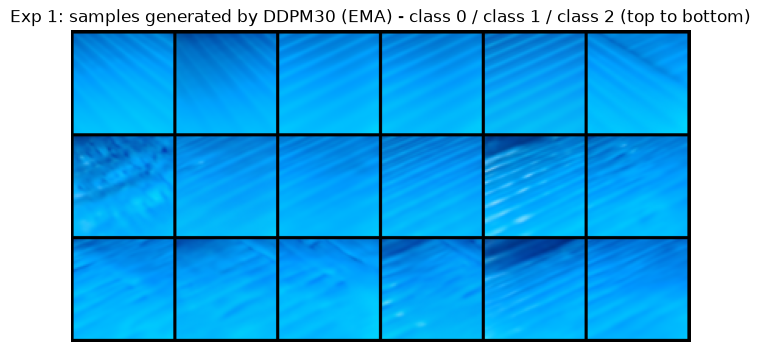

In [17]:
seed_to_show = SEEDS[0]
diffusion = onthefly_models[seed_to_show]
with torch.no_grad():
    y_vis = torch.tensor([0] * 6 + [1] * 6 + [2] * 6, device=DEVICE)
    x_vis = ddpm.sample_ddpm(diffusion, y_vis, DEVICE)
grid = make_grid(denorm(x_vis).clamp(0, 1).cpu(), nrow=6)
plt.figure(figsize=(8, 4.5))
plt.imshow(grid.permute(1, 2, 0), cmap="gray")
plt.axis("off")
plt.title(f"Exp 2: samples generated by DDPM{timesteps} (EMA) - class 0 / class 1 / class 2 (top to bottom)")
plt.show()